In [1]:
# 用 python -c 或开个临时脚本跑
import numpy as np

p = np.load("runs/plummer/phi/plots/phi_slice_xy.npz")
phi, rho, acc = p["phi"], p["rho"], p["acc_mag"]

def chk(name, a):
    print(name, a.shape, np.isfinite(a).all(), float(np.nanmin(a)), float(np.nanmax(a)))

chk("phi", phi)
chk("rho", rho)
chk("acc", acc)

# 经验性：中心加速度应更大（不要求严格，但大体趋势要对）
cy, cx = phi.shape[0]//2, phi.shape[1]//2
print("acc_center", float(acc[cy, cx]), "acc_corner", float(acc[0,0]))

phi (128, 128) True -3.0299861431121826 -2.2801570892333984
rho (128, 128) True -0.00033494349918328226 0.04841531068086624
acc (128, 128) True 0.008781762793660164 0.11807006597518921
acc_center 0.008781762793660164 acc_corner 0.10811301320791245


In [2]:
# 不依赖脚本保存额外坐标；用你跑 plot_phi_slice.py 时的 --rmax/--grid
import numpy as np

rmax = 5.0
grid = 128

p = np.load("runs/plummer/phi/plots/phi_slice_xy.npz")
acc = p["acc_mag"]

xs = np.linspace(-rmax, rmax, grid, endpoint=True)
ys = np.linspace(-rmax, rmax, grid, endpoint=True)
xx, yy = np.meshgrid(xs, ys, indexing="xy")
rr = np.sqrt(xx**2 + yy**2)

inner = acc[rr < 0.5].mean()
outer = acc[(rr > 4.0) & (rr < 5.0)].mean()
print("inner_mean", float(inner), "outer_mean", float(outer))

inner_mean 0.057323209941387177 outer_mean 0.10735540837049484


npz keys: ['x', 'y', 'phi', 'rho', 'acc_mag']
grid (128, 128) dx 0.07874011993408203
nearest_pixel_to_origin (iy,ix)= (np.int64(63), np.int64(63)) r= 0.05567769909861177 acc= 0.023887956514954567
radial_curves keys: ['r', 'phi_learned', 'phi_learned_shift', 'phi_true', 'ar_learned', 'ar_true']


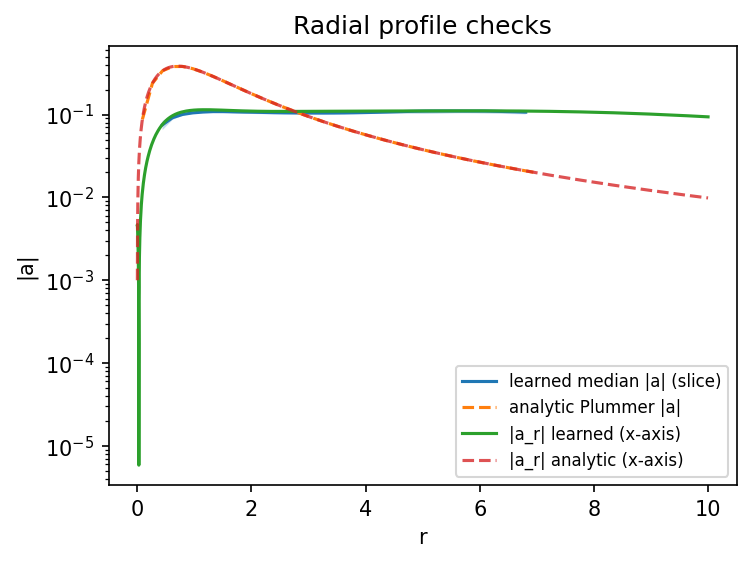

r<0.5 median/mean/count: (0.06105419434607029, 0.05732321241715302, 120)
4<r<5 median/mean/count: (0.10837049782276154, 0.10735540647003783, 4532)


In [3]:
# 径向分箱：更稳健地看 |a|(r) 的趋势，并和解析 Plummer 对比
import numpy as np
import matplotlib.pyplot as plt

p = np.load("runs/plummer/phi/plots/phi_slice_xy.npz")
print("npz keys:", p.files)

acc = np.clip(p["acc_mag"].astype(np.float64), 1e-12, np.inf)
xs = p["x"].astype(np.float64) if "x" in p.files else np.linspace(-5.0, 5.0, acc.shape[1])
ys = p["y"].astype(np.float64) if "y" in p.files else np.linspace(-5.0, 5.0, acc.shape[0])

xx, yy = np.meshgrid(xs, ys, indexing="xy")
rr = np.sqrt(xx**2 + yy**2)

# even grid 时原点通常落在像素之间；打印最近像素半径
iy, ix = np.unravel_index(np.argmin(rr), rr.shape)
print("grid", acc.shape, "dx", float(xs[1] - xs[0]))
print("nearest_pixel_to_origin (iy,ix)=", (iy, ix), "r=", float(rr[iy, ix]), "acc=", float(acc[iy, ix]))

# 径向 bins 统计（median 更抗异常值）
nb = 40
bins = np.linspace(0.0, float(rr.max()), nb + 1)
bin_id = np.digitize(rr.ravel(), bins) - 1
acc_flat = acc.ravel()

r_cent = 0.5 * (bins[:-1] + bins[1:])
a_med = np.full(nb, np.nan)
a_p16 = np.full(nb, np.nan)
a_p84 = np.full(nb, np.nan)
a_mean = np.full(nb, np.nan)

for i in range(nb):
    m = bin_id == i
    if int(m.sum()) < 50:
        continue
    vals = acc_flat[m]
    a_mean[i] = float(np.mean(vals))
    a_med[i] = float(np.median(vals))
    a_p16[i], a_p84[i] = np.percentile(vals, [16, 84])

# 解析 Plummer：Phi(r)=-1/sqrt(1+r^2) => |a| = r/(1+r^2)^(3/2)
a_true = r_cent / (1.0 + r_cent**2) ** 1.5

# 叠加 eval_phi.py 写出的径向曲线（沿 x 轴的 a_r）
rc = np.load("runs/plummer/phi/radial_curves_plummer.npz")
print("radial_curves keys:", rc.files)
r_line = rc["r"].astype(np.float64)
ar_learned = rc["ar_learned"].astype(np.float64)
ar_true = rc["ar_true"].astype(np.float64)

fig, ax = plt.subplots(1, 1, figsize=(5.4, 3.8), dpi=150)
ax.plot(r_cent, a_med, label="learned median |a| (slice)")
ax.fill_between(r_cent, a_p16, a_p84, alpha=0.25, linewidth=0)
ax.plot(r_cent, a_true, "--", label="analytic Plummer |a|")
ax.plot(r_line, np.abs(ar_learned), label="|a_r| learned (x-axis)")
ax.plot(r_line, np.abs(ar_true), "--", alpha=0.8, label="|a_r| analytic (x-axis)")
ax.set_yscale("log")
ax.set_xlabel("r")
ax.set_ylabel("|a|")
ax.set_title("Radial profile checks")
ax.legend(fontsize=8)
plt.show()

def stats(r0, r1):
    m = (rr >= r0) & (rr < r1)
    return float(np.median(acc[m])), float(np.mean(acc[m])), int(m.sum())

print("r<0.5 median/mean/count:", stats(0.0, 0.5))
print("4<r<5 median/mean/count:", stats(4.0, 5.0))

In [4]:
# 判因：固定 DF(score)，比较 learned Phi vs analytic Plummer Phi 的 residual 大小
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import yaml

from dpjax.data import Normalizer, load_eta_h5
from dpjax.flows.realnvp import RealNVP, RealNVPConfig, score_apply
from dpjax.models.potential import PotentialConfig, PotentialMLP, grad_phi_apply
from dpjax.physics.cbe import residual_A
from dpjax.utils.ckpt import create_manager, restore_latest

data_path = "data/plummer_n131072.h5"
df_run_dir = Path("runs/plummer/df")
phi_run_dir = Path("runs/plummer/phi")

norm = Normalizer.load_npz(df_run_dir / "normalizer.npz")
std_x = jnp.asarray(norm.std[:3])
mean_x = jnp.asarray(norm.mean[:3])

df_cfg = yaml.safe_load((df_run_dir / "config.yaml").read_text())
flow_cfg = df_cfg.get("flow", {})
df_model = RealNVP(
    RealNVPConfig(
        dim=int(flow_cfg.get("dim", 6)),
        n_coupling=int(flow_cfg.get("n_coupling", 10)),
        hidden_sizes=tuple(int(x) for x in flow_cfg.get("hidden_sizes", [128, 128])),
        s_max=float(flow_cfg.get("s_max", 2.0)),
    )
 )
df_params = restore_latest(create_manager(df_run_dir / "ckpt"))["params"]

phi_cfg = yaml.safe_load((phi_run_dir / "config.yaml").read_text())
pot_cfg = phi_cfg.get("potential", {})
phi_model = PotentialMLP(PotentialConfig(hidden_sizes=tuple(int(x) for x in pot_cfg.get("hidden_sizes", [256, 256, 256]))))
phi_params = restore_latest(create_manager(phi_run_dir / "ckpt"))["params"]

eta = load_eta_h5(data_path, dataset="eta")
eta_std = norm.transform(eta)
rng = np.random.default_rng(0)
idx = rng.choice(eta_std.shape[0], size=min(8192, eta_std.shape[0]), replace=False)
eta_b = jnp.asarray(eta_std[idx], dtype=jnp.float32)

@jax.jit
def residual_learned_phi(eta_std_b: jnp.ndarray) -> jnp.ndarray:
    score_std = score_apply(df_model, df_params, eta_std_b)
    grad_phi_std = grad_phi_apply(phi_model, phi_params, eta_std_b[:, :3])
    return residual_A(eta_std_b, score_std, grad_phi_std, norm)

@jax.jit
def residual_true_plummer_phi(eta_std_b: jnp.ndarray) -> jnp.ndarray:
    score_std = score_apply(df_model, df_params, eta_std_b)
    x_std = eta_std_b[:, :3]
    x_phys = x_std * std_x[None, :] + mean_x[None, :]
    r2 = jnp.sum(x_phys**2, axis=-1, keepdims=True)
    grad_phi_phys = x_phys * (1.0 + r2) ** (-1.5)  # ∇Phi in physical coords
    grad_phi_std = grad_phi_phys * std_x[None, :]  # convert back to ∇_{x_std} Phi
    return residual_A(eta_std_b, score_std, grad_phi_std, norm)

rL = np.asarray(residual_learned_phi(eta_b))
rT = np.asarray(residual_true_plummer_phi(eta_b))

def summarize(name: str, r: np.ndarray) -> None:
    print(
        name,
        "mean", float(np.mean(r)),
"std", float(np.std(r)),
"p99_abs", float(np.percentile(np.abs(r), 99.0)),
"max_abs", float(np.max(np.abs(r))),
)

summarize("residual(learned_phi)", rL)
summarize("residual(true_plummer_phi)", rT)
print("std ratio true/learned:", float(np.std(rT) / (np.std(rL) + 1e-12)))

residual(learned_phi) mean 0.00019207521108910441 std 0.19756747782230377 p99_abs 0.7650954127311707 max_abs 2.819394588470459
residual(true_plummer_phi) mean -0.0024263521190732718 std 0.5936257839202881 p99_abs 1.477006435394287 max_abs 3.9028055667877197
std ratio true/learned: 3.004673480987549
